# 🌾 PaddyGuard AI — NLP Disease Classifier Training
### Component 1 · Multi-Model Comparison Study

**Models trained:**
1. TF-IDF + Naive Bayes
2. TF-IDF + Logistic Regression
3. TF-IDF + Random Forest
4. TF-IDF + SVM *(your proposal baseline)*
5. DistilBERT
6. BERT (bert-base-uncased)

**Classes:** Bacterial Blight (0) · Leaf Blast (1) · Brown Spot (2) · Healthy (3)


In [ ]:
# CELL 1 — Install
!pip install -q pandas scikit-learn matplotlib seaborn joblib
!pip install -q transformers torch datasets accelerate
print('✅ All libraries installed')

✅ All libraries installed


In [ ]:
# CELL 2 — Imports
import pandas as pd
import numpy as np
import re, time, os, joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix)
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer)
from torch.utils.data import Dataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports done  |  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Imports done  |  Device: cuda
   GPU: Tesla T4


Total rows   : 800
Columns      : ['text', 'label', 'label_id']

Class distribution:
  [0] Bacterial Blight     200
  [1] Leaf Blast           200
  [2] Brown Spot           200
  [3] Healthy              200


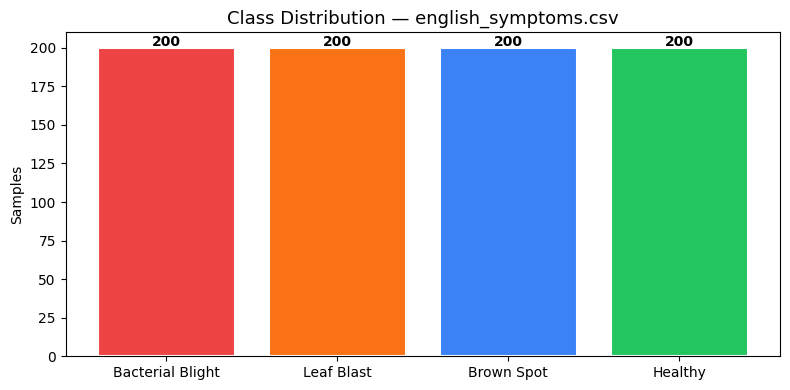

✅ Dataset loaded


In [ ]:
# CELL 3 — Load & Explore Dataset
df = pd.read_csv('english_symptoms.csv')
LABEL_MAP = {0:'Bacterial Blight', 1:'Leaf Blast', 2:'Brown Spot', 3:'Healthy'}
COLORS    = ['#ef4444','#f97316','#3b82f6','#22c55e']

print(f'Total rows   : {len(df)}')
print(f'Columns      : {list(df.columns)}')
print('\nClass distribution:')
for lid, lname in LABEL_MAP.items():
    count = len(df[df['label_id']==lid])
    print(f'  [{lid}] {lname:<20} {count}')

fig, ax = plt.subplots(figsize=(8,4))
counts = [len(df[df['label_id']==i]) for i in range(4)]
bars = ax.bar(LABEL_MAP.values(), counts, color=COLORS, edgecolor='white', linewidth=1.5)
for bar,c in zip(bars,counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(c), ha='center', fontweight='bold')
ax.set_title('Class Distribution — english_symptoms.csv', fontsize=13)
ax.set_ylabel('Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('✅ Dataset loaded')

In [ ]:
# CELL 4 — Pre-processing
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)
df['label_id']   = df['label_id'].astype(int)

print('Pre-processing examples:')
for _, row in df.sample(4, random_state=7).iterrows():
    print(f'  BEFORE: "{row["text"]}"')
    print(f'  AFTER : "{row["text_clean"]}"')
    print()
print('✅ Pre-processing done')

Pre-processing examples:
  BEFORE: "stunted paddy, yellow stripes"
  AFTER : "stunted paddy yellow stripes"

  BEFORE: "no disease sign, healthy paddy"
  AFTER : "no disease sign healthy paddy"

  BEFORE: "leaf no lesion, healthy"
  AFTER : "leaf no lesion healthy"

  BEFORE: "paddy blast, grey spot"
  AFTER : "paddy blast grey spot"

✅ Pre-processing done


In [ ]:
# CELL 5 — Train / Validation / Test Split  (70 / 15 / 15)
X_raw   = df['text'].values        # raw text  → for BERT
X_clean = df['text_clean'].values  # cleaned   → for classical ML
y       = df['label_id'].values

X_raw_tr, X_raw_tmp, X_cl_tr, X_cl_tmp, y_tr, y_tmp = train_test_split(
    X_raw, X_clean, y, test_size=0.30, random_state=42, stratify=y)
X_raw_val, X_raw_te, X_cl_val, X_cl_te, y_val, y_te = train_test_split(
    X_raw_tmp, X_cl_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f'✅ Split complete')
print(f'   Train      : {len(y_tr)} rows (70%)')
print(f'   Validation : {len(y_val)} rows (15%)')
print(f'   Test       : {len(y_te)} rows (15%)')
from collections import Counter
for name, ys in [('Train',y_tr),('Val',y_val),('Test',y_te)]:
    c = Counter(ys)
    print(f'   {name}: { {LABEL_MAP[k]:v for k,v in sorted(c.items())} }')

✅ Split complete
   Train      : 560 rows (70%)
   Validation : 120 rows (15%)
   Test       : 120 rows (15%)
   Train: {'Bacterial Blight': 140, 'Leaf Blast': 140, 'Brown Spot': 140, 'Healthy': 140}
   Val: {'Bacterial Blight': 30, 'Leaf Blast': 30, 'Brown Spot': 30, 'Healthy': 30}
   Test: {'Bacterial Blight': 30, 'Leaf Blast': 30, 'Brown Spot': 30, 'Healthy': 30}


In [ ]:
# CELL 6 — TF-IDF Vectorisation (for classical ML models)
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=2, sublinear_tf=True)
X_tr_tfidf  = tfidf.fit_transform(X_cl_tr)
X_val_tfidf = tfidf.transform(X_cl_val)
X_te_tfidf  = tfidf.transform(X_cl_te)

print(f'✅ TF-IDF done')
print(f'   Vocabulary  : {len(tfidf.vocabulary_)} terms')
print(f'   Train matrix: {X_tr_tfidf.shape}')
print(f'   Top 15 terms: {list(tfidf.get_feature_names_out()[:15])}')

✅ TF-IDF done
   Vocabulary  : 445 terms
   Train matrix: (560, 445)
   Top 15 terms: ['307', '307 variety', 'after', 'after rain', 'all', 'all over', 'along', 'around', 'ash', 'ash colored', 'ash grey', 'at', 'bacterial', 'bacterial blight', 'bacterial stripe']


In [ ]:
# CELL 7 — Evaluation helper (stores all model results)
RESULTS = {}

def evaluate_model(name, y_true, y_pred, y_proba, train_time, size_mb):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    high_conf = round((y_proba.max(axis=1) >= 0.70).mean()*100, 1) if y_proba is not None else 'N/A'
    RESULTS[name] = {
        'Accuracy': round(acc*100,2), 'Precision': round(prec*100,2),
        'Recall':   round(rec*100,2), 'F1-Score':  round(f1*100,2),
        'Train Time (s)': round(train_time,2), 'Model Size (MB)': round(size_mb,2),
        'High Conf %': high_conf, 'y_true': y_true, 'y_pred': y_pred
    }
    print(f'\n=== {name} ===')
    print(f'  Accuracy : {acc*100:.2f}%  |  F1: {f1*100:.2f}%  |  Train: {train_time:.1f}s  |  Size: {size_mb:.1f}MB')
    print(classification_report(y_true, y_pred, target_names=list(LABEL_MAP.values())))

def model_mb(path):
    return os.path.getsize(path)/(1024*1024) if os.path.exists(path) else 0.0

print('✅ Evaluation helper ready')

✅ Evaluation helper ready


In [ ]:
# CELL 8 — Model 1: TF-IDF + Naive Bayes
t0 = time.time()
nb = MultinomialNB(alpha=0.1)
nb.fit(X_tr_tfidf, y_tr)
joblib.dump(nb, 'model_nb.pkl')
evaluate_model('Naive Bayes', y_te,
    nb.predict(X_te_tfidf), nb.predict_proba(X_te_tfidf),
    time.time()-t0, model_mb('model_nb.pkl'))


=== Naive Bayes ===
  Accuracy : 95.00%  |  F1: 94.98%  |  Train: 0.0s  |  Size: 0.0MB
                  precision    recall  f1-score   support

Bacterial Blight       0.97      0.93      0.95        30
      Leaf Blast       0.93      0.93      0.93        30
      Brown Spot       0.97      0.93      0.95        30
         Healthy       0.94      1.00      0.97        30

        accuracy                           0.95       120
       macro avg       0.95      0.95      0.95       120
    weighted avg       0.95      0.95      0.95       120



In [ ]:
# CELL 9 — Model 2: TF-IDF + Logistic Regression
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42)
lr.fit(X_tr_tfidf, y_tr)
joblib.dump(lr, 'model_lr.pkl')
evaluate_model('Logistic Regression', y_te,
    lr.predict(X_te_tfidf), lr.predict_proba(X_te_tfidf),
    time.time()-t0, model_mb('model_lr.pkl'))


=== Logistic Regression ===
  Accuracy : 95.00%  |  F1: 94.97%  |  Train: 0.0s  |  Size: 0.0MB
                  precision    recall  f1-score   support

Bacterial Blight       0.91      1.00      0.95        30
      Leaf Blast       0.93      0.90      0.92        30
      Brown Spot       0.96      0.90      0.93        30
         Healthy       1.00      1.00      1.00        30

        accuracy                           0.95       120
       macro avg       0.95      0.95      0.95       120
    weighted avg       0.95      0.95      0.95       120



In [ ]:
# CELL 10 — Model 3: TF-IDF + Random Forest  (~2-3 min)
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr_tfidf, y_tr)
joblib.dump(rf, 'model_rf.pkl')
evaluate_model('Random Forest', y_te,
    rf.predict(X_te_tfidf), rf.predict_proba(X_te_tfidf),
    time.time()-t0, model_mb('model_rf.pkl'))


=== Random Forest ===
  Accuracy : 95.00%  |  F1: 95.00%  |  Train: 1.7s  |  Size: 3.9MB
                  precision    recall  f1-score   support

Bacterial Blight       0.88      1.00      0.94        30
      Leaf Blast       0.93      0.90      0.92        30
      Brown Spot       1.00      0.90      0.95        30
         Healthy       1.00      1.00      1.00        30

        accuracy                           0.95       120
       macro avg       0.95      0.95      0.95       120
    weighted avg       0.95      0.95      0.95       120



In [ ]:
# CELL 11 — Model 4: TF-IDF + SVM
t0  = time.time()
svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=5)
svm.fit(X_tr_tfidf, y_tr)
joblib.dump(svm, 'model_svm.pkl')
evaluate_model('SVM', y_te,
    svm.predict(X_te_tfidf), svm.predict_proba(X_te_tfidf),
    time.time()-t0, model_mb('model_svm.pkl'))


=== SVM ===
  Accuracy : 96.67%  |  F1: 96.65%  |  Train: 1.0s  |  Size: 0.1MB
                  precision    recall  f1-score   support

Bacterial Blight       0.97      1.00      0.98        30
      Leaf Blast       0.93      0.93      0.93        30
      Brown Spot       0.97      0.93      0.95        30
         Healthy       1.00      1.00      1.00        30

        accuracy                           0.97       120
       macro avg       0.97      0.97      0.97       120
    weighted avg       0.97      0.97      0.97       120



In [ ]:
# CELL 12 — Shared Dataset class for DistilBERT & BERT
class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'f1': f1_score(labels, preds, average='weighted')}

def folder_mb(path):
    return sum(os.path.getsize(os.path.join(path,f)) for f in os.listdir(path))/(1024*1024)

print('✅ BERT Dataset class ready')

✅ BERT Dataset class ready


In [ ]:
# CELL 13 — Model 5: DistilBERT  (~15-20 min on T4)
DB_ID = 'distilbert-base-uncased'
db_tok   = AutoTokenizer.from_pretrained(DB_ID)
db_model = AutoModelForSequenceClassification.from_pretrained(DB_ID, num_labels=4)

db_args = TrainingArguments(
    output_dir='./db_out', num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    warmup_steps=100, weight_decay=0.01, learning_rate=2e-5,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1',
    logging_steps=20, report_to='none'
)
db_trainer = Trainer(
    model=db_model, args=db_args,
    train_dataset=SymptomDataset(X_raw_tr, y_tr,  db_tok),
    eval_dataset =SymptomDataset(X_raw_val,y_val, db_tok),
    compute_metrics=compute_metrics
)
t0 = time.time()
db_trainer.train()
tt = time.time()-t0

db_raw   = db_trainer.predict(SymptomDataset(X_raw_te, y_te, db_tok))
db_proba = torch.softmax(torch.tensor(db_raw.predictions),dim=1).numpy()
db_pred  = np.argmax(db_raw.predictions, axis=1)

db_trainer.save_model('./distilbert_saved')
db_tok.save_pretrained('./distilbert_saved')
evaluate_model('DistilBERT', y_te, db_pred, db_proba, tt, folder_mb('./distilbert_saved'))
print('✅ DistilBERT saved to ./distilbert_saved')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== DistilBERT ===
  Accuracy : 95.00%  |  F1: 94.95%  |  Train: 44.1s  |  Size: 256.1MB
                  precision    recall  f1-score   support

Bacterial Blight       0.93      0.93      0.93        30
      Leaf Blast       0.96      0.87      0.91        30
      Brown Spot       0.91      1.00      0.95        30
         Healthy       1.00      1.00      1.00        30

        accuracy                           0.95       120
       macro avg       0.95      0.95      0.95       120
    weighted avg       0.95      0.95      0.95       120

✅ DistilBERT saved to ./distilbert_saved


In [ ]:
# CELL 14 — Model 6: BERT  (~25-35 min on T4)
BERT_ID = 'bert-base-uncased'
bt       = AutoTokenizer.from_pretrained(BERT_ID)
bt_model = AutoModelForSequenceClassification.from_pretrained(BERT_ID, num_labels=4)

bt_args = TrainingArguments(
    output_dir='./bert_out', num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    warmup_steps=100, weight_decay=0.01, learning_rate=2e-5,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1',
    logging_steps=20, report_to='none'
)
bt_trainer = Trainer(
    model=bt_model, args=bt_args,
    train_dataset=SymptomDataset(X_raw_tr, y_tr,  bt),
    eval_dataset =SymptomDataset(X_raw_val,y_val, bt),
    compute_metrics=compute_metrics
)
t0 = time.time()
bt_trainer.train()
tt = time.time()-t0

bt_raw   = bt_trainer.predict(SymptomDataset(X_raw_te, y_te, bt))
bt_proba = torch.softmax(torch.tensor(bt_raw.predictions),dim=1).numpy()
bt_pred  = np.argmax(bt_raw.predictions, axis=1)

bt_trainer.save_model('./bert_saved')
bt.save_pretrained('./bert_saved')
evaluate_model('BERT', y_te, bt_pred, bt_proba, tt, folder_mb('./bert_saved'))
print('✅ BERT saved to ./bert_saved')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== BERT ===
  Accuracy : 94.17%  |  F1: 94.17%  |  Train: 266.4s  |  Size: 418.4MB
                  precision    recall  f1-score   support

Bacterial Blight       0.88      0.97      0.92        30
      Leaf Blast       0.93      0.90      0.92        30
      Brown Spot       0.96      0.90      0.93        30
         Healthy       1.00      1.00      1.00        30

        accuracy                           0.94       120
       macro avg       0.94      0.94      0.94       120
    weighted avg       0.94      0.94      0.94       120

✅ BERT saved to ./bert_saved


In [ ]:
# CELL 15 — Comparison Table  (your research paper table)
ORDER = ['Naive Bayes','Logistic Regression','Random Forest','SVM','DistilBERT','BERT']
rows  = []
for name in ORDER:
    if name not in RESULTS: continue
    r = RESULTS[name]
    rows.append({'Model':name, 'Accuracy (%)':r['Accuracy'],
                 'Precision (%)':r['Precision'], 'Recall (%)':r['Recall'],
                 'F1-Score (%)':r['F1-Score'], 'Train Time (s)':r['Train Time (s)'],
                 'Model Size (MB)':r['Model Size (MB)'], 'High Conf % (τ≥0.70)':r['High Conf %']})

results_df = pd.DataFrame(rows)
best = results_df.loc[results_df['F1-Score (%)'].idxmax()]

print('\n' + '='*85)
print('  COMPARISON TABLE — All Models')
print('='*85)
print(results_df.to_string(index=False))
print('='*85)
print(f'\n🏆 Best model (F1): {best["Model"]}  F1={best["F1-Score (%)"]:.2f}%  Acc={best["Accuracy (%)"]:.2f}%')

results_df.to_csv('paddyguard_model_comparison.csv', index=False)
print('\n✅ Results saved → paddyguard_model_comparison.csv')


  COMPARISON TABLE — All Models
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Train Time (s)  Model Size (MB)  High Conf % (τ≥0.70)
        Naive Bayes         95.00          95.05       95.00         94.98            0.01             0.03                  94.2
Logistic Regression         95.00          95.11       95.00         94.97            0.04             0.01                  65.0
      Random Forest         95.00          95.33       95.00         95.00            1.67             3.93                  95.0
                SVM         96.67          96.66       96.67         96.65            1.00             0.07                  93.3
         DistilBERT         95.00          95.13       95.00         94.95           44.06           256.12                  97.5
               BERT         94.17          94.35       94.17         94.17          266.43           418.36                  90.8

🏆 Best model (F1): SVM  F1=96.65%  Acc=96.67%

✅ Results

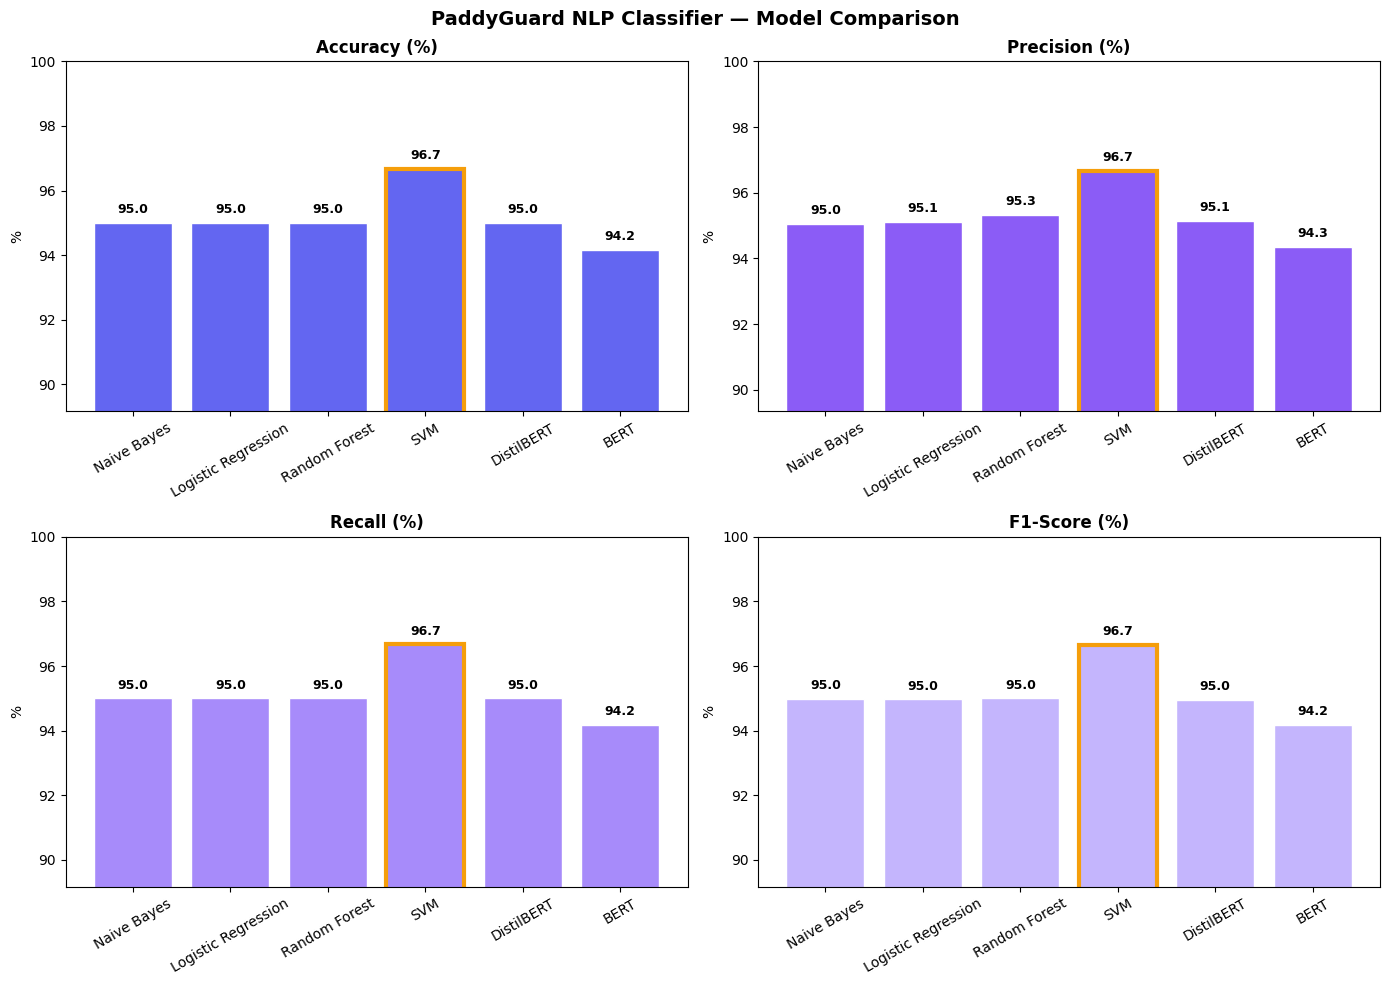

✅ Bar chart saved → model_comparison_bars.png


In [ ]:
# CELL 16 — Visualisation: Bar Chart Comparison
metrics     = ['Accuracy (%)','Precision (%)','Recall (%)','F1-Score (%)']
bar_colors  = ['#6366f1','#8b5cf6','#a78bfa','#c4b5fd']
model_names = results_df['Model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PaddyGuard NLP Classifier — Model Comparison', fontsize=14, fontweight='bold')

for ax, metric, color in zip(axes.flat, metrics, bar_colors):
    values = results_df[metric].tolist()
    bars   = ax.bar(model_names, values, color=color, edgecolor='white', linewidth=1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(max(0, min(values)-5), 100)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
    bars[values.index(max(values))].set_edgecolor('#f59e0b')
    bars[values.index(max(values))].set_linewidth(3)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Bar chart saved → model_comparison_bars.png')

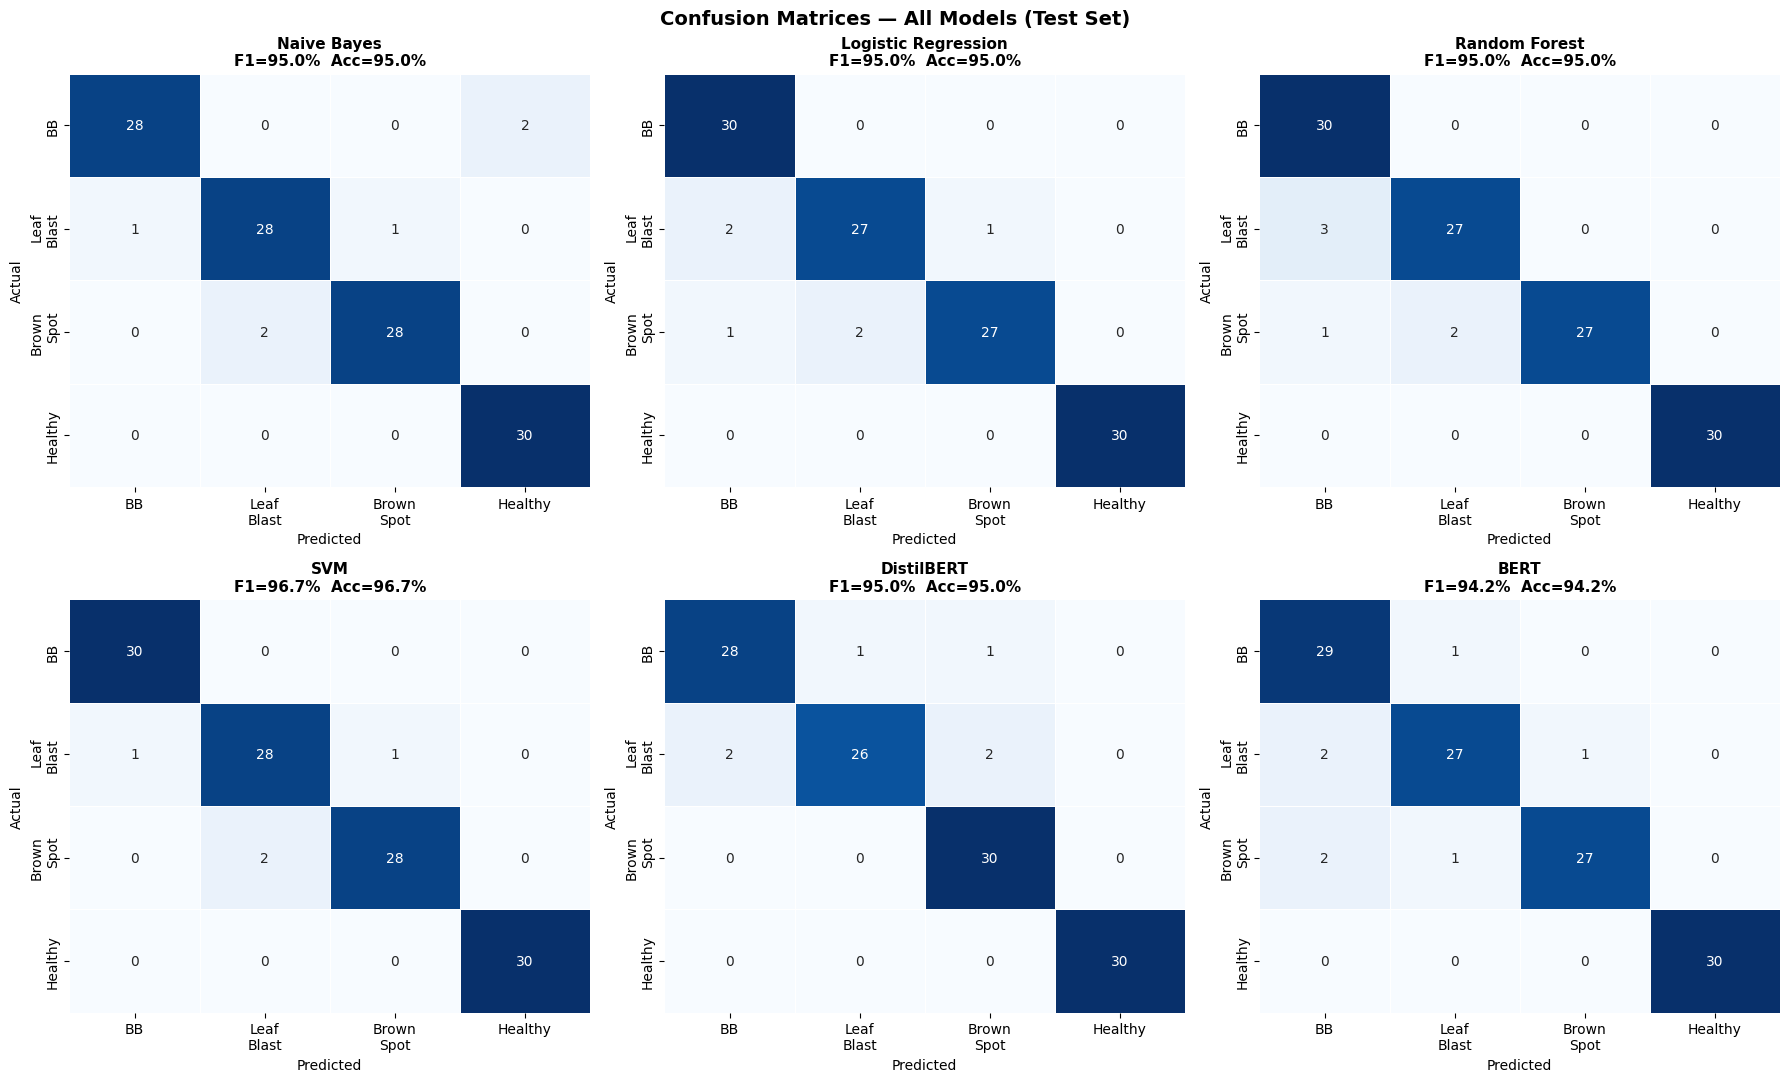

✅ Confusion matrices saved → all_confusion_matrices.png


In [ ]:
# CELL 17 — All Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
label_names = ['BB','Leaf\nBlast','Brown\nSpot','Healthy']

for ax, name in zip(axes.flat, ORDER):
    if name not in RESULTS: ax.axis('off'); continue
    cm = confusion_matrix(RESULTS[name]['y_true'], RESULTS[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=label_names, yticklabels=label_names, linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nF1={RESULTS[name]["F1-Score"]:.1f}%  Acc={RESULTS[name]["Accuracy"]:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved → all_confusion_matrices.png')

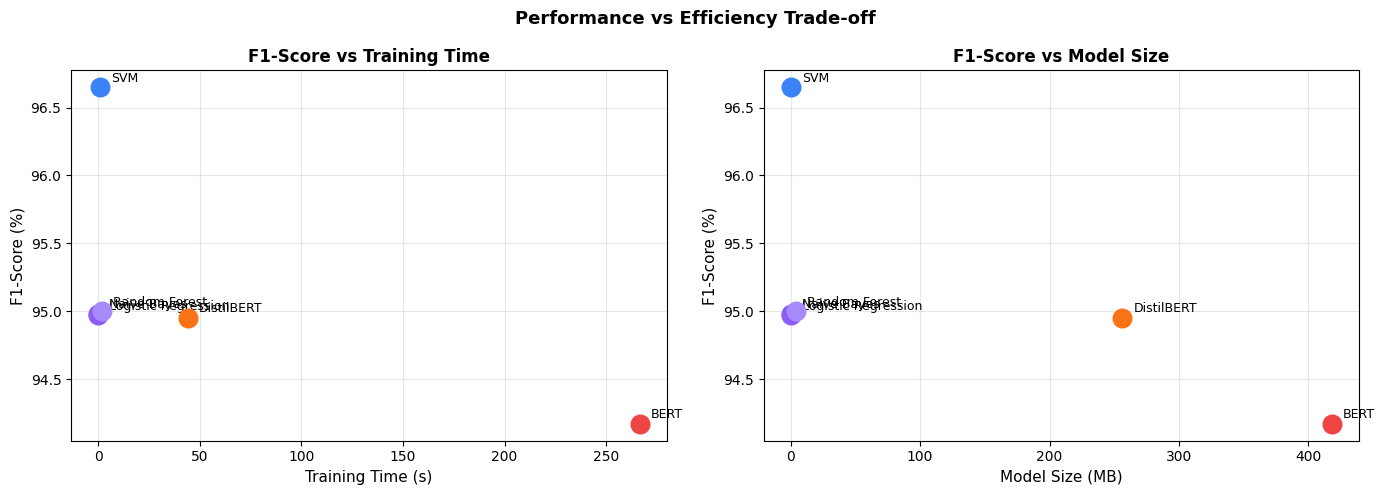

✅ Trade-off chart saved → tradeoff_analysis.png


In [ ]:
# CELL 18 — F1 vs Train Time vs Model Size (trade-off chart)
colors = ['#6366f1','#8b5cf6','#a78bfa','#3b82f6','#f97316','#ef4444']
done   = [m for m in ORDER if m in RESULTS]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for i, name in enumerate(done):
    r = RESULTS[name]
    axes[0].scatter(r['Train Time (s)'], r['F1-Score'], color=colors[i], s=180, zorder=5)
    axes[0].annotate(name, (r['Train Time (s)'], r['F1-Score']),
        textcoords='offset points', xytext=(8,4), fontsize=9)
    axes[1].scatter(r['Model Size (MB)'], r['F1-Score'], color=colors[i], s=180, zorder=5)
    axes[1].annotate(name, (r['Model Size (MB)'], r['F1-Score']),
        textcoords='offset points', xytext=(8,4), fontsize=9)

for ax, xlabel in zip(axes, ['Training Time (s)','Model Size (MB)']):
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('F1-Score (%)', fontsize=11)
    ax.grid(True, alpha=0.3)
axes[0].set_title('F1-Score vs Training Time', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score vs Model Size',    fontsize=12, fontweight='bold')

plt.suptitle('Performance vs Efficiency Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tradeoff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Trade-off chart saved → tradeoff_analysis.png')

In [ ]:
# CELL 19 — Save best model for voice pipeline notebook
best_name = results_df.loc[results_df['F1-Score (%)'].idxmax(), 'Model']
clf_map   = {'Naive Bayes':('model_nb.pkl',nb),
             'Logistic Regression':('model_lr.pkl',lr),
             'Random Forest':('model_rf.pkl',rf),
             'SVM':('model_svm.pkl',svm)}

print(f'🏆 Best model: {best_name}')

if best_name in clf_map:
    _, clf = clf_map[best_name]
    joblib.dump(clf,   'paddyguard_best_classifier.pkl')
    joblib.dump(tfidf, 'paddyguard_tfidf.pkl')
    print('✅ Saved:')
    print('   paddyguard_best_classifier.pkl')
    print('   paddyguard_tfidf.pkl')
else:
    folder = './distilbert_saved' if 'DistilBERT' in best_name else './bert_saved'
    print(f'✅ Best model folder: {folder}')
    print('   Download the full folder for your voice pipeline')

print('\n' + '='*55)
print('  TRAINING COMPLETE — Download these files:')
print('  paddyguard_model_comparison.csv  ← paper table')
print('  model_comparison_bars.png        ← paper figure')
print('  all_confusion_matrices.png       ← paper figure')
print('  tradeoff_analysis.png            ← paper figure')
print('  paddyguard_best_classifier.pkl   ← voice pipeline')
print('  paddyguard_tfidf.pkl             ← voice pipeline')
print('='*55)

🏆 Best model: SVM
✅ Saved:
   paddyguard_best_classifier.pkl
   paddyguard_tfidf.pkl

  TRAINING COMPLETE — Download these files:
  paddyguard_model_comparison.csv  ← paper table
  model_comparison_bars.png        ← paper figure
  all_confusion_matrices.png       ← paper figure
  tradeoff_analysis.png            ← paper figure
  paddyguard_best_classifier.pkl   ← voice pipeline
  paddyguard_tfidf.pkl             ← voice pipeline


---
## 🚫 Out-of-Distribution (OOD) Detection
**Confidence Threshold Method** — No extra dataset, no retraining needed.

When the model is confused by an unrelated input, all 4 class probabilities spread out evenly and the max score drops low. We use this as our OOD signal.

```
Disease symptom  →  BB=0.89  LB=0.06  BS=0.03  HE=0.02  → max=0.89 → ✅ Classified
Unrelated input  →  BB=0.31  LB=0.28  BS=0.22  HE=0.19  → max=0.31 → 🚫 OOD detected
```

**Thresholds used:**
- `τ_ood = 0.40` — below this → Unknown / OOD
- `τ_followup = 0.70` — between 0.40–0.70 → ask follow-up question
- `≥ 0.70` → confident disease classification

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 20 (IMPROVED) — OOD Detection with Entropy + Threshold
# Combines two signals for much better OOD detection
# ═══════════════════════════════════════════════════════════

import numpy as np
from scipy.stats import entropy as scipy_entropy

OOD_THRESHOLD      = 0.50   # ← raised from 0.40 to 0.50
FOLLOWUP_THRESHOLD = 0.70
ENTROPY_THRESHOLD  = 1.20   # ← new: high entropy = uncertain = OOD
MIN_SYMPTOM_WORDS  = 1      # ← new: must match at least 1 known symptom word

# Key symptom words from your training vocabulary
# If NONE of these appear in the input → definitely OOD
SYMPTOM_VOCABULARY = set([
    # Disease indicators
    'leaf', 'leaves', 'paddy', 'rice', 'plant', 'stem', 'spot', 'spots',
    'lesion', 'lesions', 'stripe', 'yellow', 'brown', 'grey', 'gray',
    'white', 'ooze', 'blast', 'blight', 'disease', 'symptom', 'infection',
    'healthy', 'green', 'blade', 'margin', 'vein', 'tip', 'node', 'neck',
    'grain', 'panicle', 'seedling', 'tiller', 'oval', 'circular', 'diamond',
    'spindle', 'fungal', 'bacterial', 'dots', 'marks', 'discoloration',
    'wilting', 'wilt', 'rot', 'halo', 'border', 'center', 'necrotic',
    'kresek', 'BG-307', 'water-soaked', 'wavy', 'scattered', 'dense',
    # Sinhala-origin words that appear in English form
    'paddy', 'goyam', 'kola', 'ooze'
])

def has_symptom_words(text: str) -> bool:
    """Check if input contains at least one known symptom word."""
    words = set(text.lower().split())
    return len(words & SYMPTOM_VOCABULARY) >= MIN_SYMPTOM_WORDS

def classify_with_ood(english_text,
                      ood_threshold=OOD_THRESHOLD,
                      followup_threshold=FOLLOWUP_THRESHOLD):
    """
    Improved OOD detection using 3 signals:
    1. Vocabulary check — does it contain any symptom words?
    2. Confidence threshold — is max probability high enough?
    3. Entropy check — is the distribution uncertain?
    """
    clean = preprocess_text(english_text)

    # ── Signal 1: Vocabulary check (fastest filter) ───────────────
    if not has_symptom_words(english_text):
        return {
            'input_text'    : english_text,
            'disease'       : 'Unknown / OOD',
            'label_id'      : -1,
            'confidence'    : 0.0,
            'is_ood'        : True,
            'ood_reason'    : 'No disease-related vocabulary detected',
            'needs_followup': False,
            'status'        : '🚫 OOD — No symptom vocabulary',
            'message'       : 'Please describe the symptoms of your paddy plant.',
            'all_scores'    : {LABEL_MAP[i]: 0.0 for i in range(4)}
        }

    # ── Signal 2 & 3: SVM probability + entropy ───────────────────
    vec        = tfidf.transform([clean])
    proba      = svm.predict_proba(vec)[0]
    confidence = float(proba.max())
    label_id   = int(proba.argmax())

    # Entropy: uniform distribution (max uncertainty) = log2(4) ≈ 2.0
    # Low entropy = confident, High entropy = uncertain = likely OOD
    ent = float(scipy_entropy(proba, base=2))

    all_scores = {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)}

    # ── OOD decision: fail EITHER threshold OR entropy check ──────
    is_ood = (confidence < ood_threshold) or (ent > ENTROPY_THRESHOLD)

    if is_ood:
        reason = []
        if confidence < ood_threshold:
            reason.append(f'low confidence ({confidence:.2f} < {ood_threshold})')
        if ent > ENTROPY_THRESHOLD:
            reason.append(f'high entropy ({ent:.2f} > {ENTROPY_THRESHOLD})')
        return {
            'input_text'    : english_text,
            'disease'       : 'Unknown / OOD',
            'label_id'      : -1,
            'confidence'    : round(confidence, 4),
            'entropy'       : round(ent, 4),
            'is_ood'        : True,
            'ood_reason'    : ' + '.join(reason),
            'needs_followup': False,
            'status'        : '🚫 OOD — Not a disease symptom',
            'message'       : 'Input does not appear to be a rice disease description. '
                              'Please describe symptoms of your paddy plant.',
            'all_scores'    : all_scores
        }

    # ── In-distribution result ────────────────────────────────────
    needs_followup = confidence < followup_threshold
    return {
        'input_text'    : english_text,
        'disease'       : LABEL_MAP[label_id],
        'label_id'      : label_id,
        'confidence'    : round(confidence, 4),
        'entropy'       : round(ent, 4),
        'is_ood'        : False,
        'needs_followup': needs_followup,
        'status'        : '⚠️  Low confidence — ask follow-up' if needs_followup
                          else '✅ Confident classification',
        'message'       : None,
        'all_scores'    : all_scores
    }

print('✅ Improved OOD detection ready')
print(f'   Signal 1: vocabulary check (symptom word list)')
print(f'   Signal 2: confidence threshold τ_ood = {OOD_THRESHOLD}')
print(f'   Signal 3: entropy threshold τ_entropy = {ENTROPY_THRESHOLD}')
print(f'   OOD triggered if ANY signal fires')

✅ Improved OOD detection ready
   Signal 1: vocabulary check (symptom word list)
   Signal 2: confidence threshold τ_ood = 0.5
   Signal 3: entropy threshold τ_entropy = 1.2
   OOD triggered if ANY signal fires


In [ ]:
# CELL 21 — Quick OOD Test

test_inputs = [
    # ── In-distribution (disease symptoms) ──────────────────
    ('leaf edges yellow from the tips',           'IN  — BB'),
    ('yellow stripe running down leaf margin',    'IN  — BB'),
    ('white ooze from cut stem in water',         'IN  — BB'),
    ('diamond shaped spots grey center',          'IN  — LB'),
    ('grey lesion brown border blast',            'IN  — LB'),
    ('BG-307 leaf blast grey spots',              'IN  — LB'),
    ('many small brown dots on leaf',             'IN  — BS'),
    ('oval brown lesion yellow halo',             'IN  — BS'),
    ('no spots healthy green paddy',              'IN  — HE'),
    ('leaf clean no disease',                     'IN  — HE'),
    # ── Out-of-distribution (unrelated inputs) ───────────────
    ('the weather is very hot today',             'OOD'),
    ('i am going to the market',                  'OOD'),
    ('my child is sick with fever',               'OOD'),
    ('hello testing microphone one two three',    'OOD'),
    ('the bus is late today',                     'OOD'),
    ('cow is not eating grass',                   'OOD'),
    ('good morning how are you',                  'OOD'),
    ('please help me find directions',            'OOD'),
    ('what time is it now',                       'OOD'),
    ('the road is broken',                        'OOD'),
]

print('='*75)
print(f'  {"Input text":<42} {"Expected":<10} {"Result":<18} {"Conf"}')
print('='*75)

correct = 0
for text, expected in test_inputs:
    r = classify_with_ood(text)
    predicted = 'OOD' if r['is_ood'] else r['disease'][:14]
    is_correct = (
        (r['is_ood'] and expected == 'OOD') or
        (not r['is_ood'] and expected.startswith('IN'))
    )
    correct += int(is_correct)
    tick = '✅' if is_correct else '❌'
    print(f'  {tick} {text[:40]:<42} {expected:<10} {predicted:<18} {r["confidence"]:.3f}')

print('='*75)
print(f'  Correct: {correct}/{len(test_inputs)}  ({correct/len(test_inputs)*100:.1f}%)')


  Input text                                 Expected   Result             Conf
  ✅ leaf edges yellow from the tips            IN  — BB   Bacterial Blig     0.936
  ✅ yellow stripe running down leaf margin     IN  — BB   Bacterial Blig     0.983
  ✅ white ooze from cut stem in water          IN  — BB   Bacterial Blig     0.954
  ✅ diamond shaped spots grey center           IN  — LB   Leaf Blast         0.988
  ✅ grey lesion brown border blast             IN  — LB   Leaf Blast         0.986
  ✅ BG-307 leaf blast grey spots               IN  — LB   Leaf Blast         0.984
  ✅ many small brown dots on leaf              IN  — BS   Brown Spot         0.909
  ✅ oval brown lesion yellow halo              IN  — BS   Brown Spot         0.961
  ✅ no spots healthy green paddy               IN  — HE   Healthy            0.979
  ✅ leaf clean no disease                      IN  — HE   Healthy            0.977
  ✅ the weather is very hot today              OOD        OOD                0.000
  ✅ i a

  OOD DETECTION EVALUATION — Confidence Threshold
  Method  : Confidence Threshold (τ_ood = 0.5)
  Dataset : No OOD training data — zero-shot
  True Positives  (OOD correctly flagged) : 25/25
  False Negatives (OOD missed)            : 0/25
  True Negatives  (In-dist accepted)      : 25/25
  False Positives (In-dist wrongly flagged): 0/25
───────────────────────────────────────────────────────
  OOD Detection Rate   : 100.0%
  False Rejection Rate : 0.0%
  OOD Precision        : 100.0%
  Avg confidence — In-dist : 0.949
  Avg confidence — OOD    : 0.000


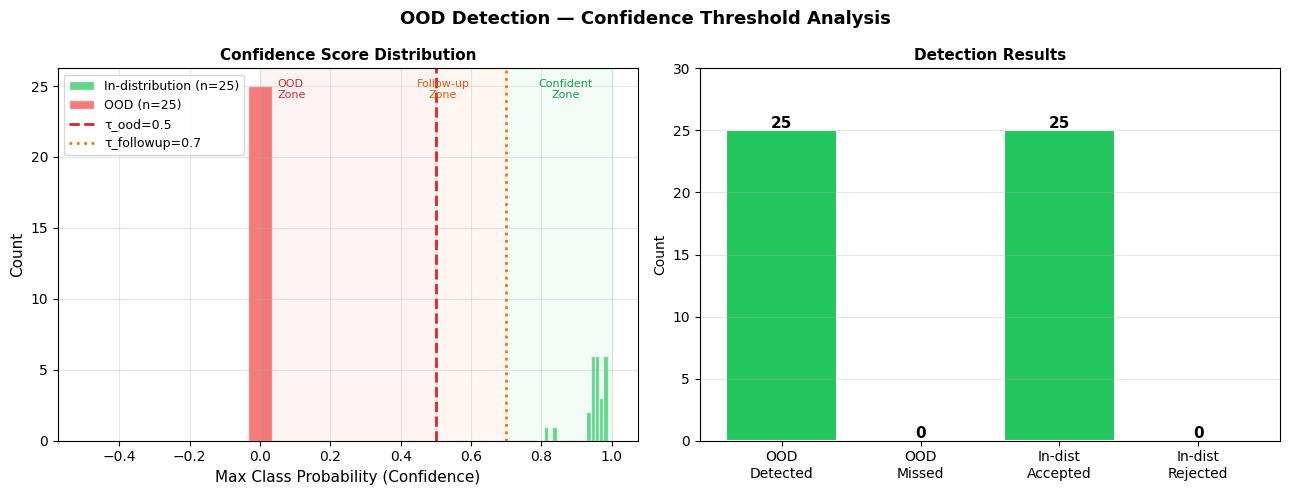

✅ OOD analysis chart saved → ood_analysis.png


In [ ]:
# CELL 22 — OOD Evaluation Report  (for your research paper)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Larger evaluation set ────────────────────────────────────────────
in_dist_eval = [
    'leaf edges yellow from tip',
    'yellow stripe leaf margin',
    'white ooze stem cut water',
    'kresek seedling wilting',
    'water soaked lesion leaf margin',
    'bacterial ooze milky white',
    'vein limited yellow lesion',
    'leaf tip white stripe',
    'diamond shaped spot leaf',
    'grey center brown border blast',
    'spindle lesion paddy leaf',
    'neck blast white head',
    'BG-307 blast grey spots',
    'blast spots upper leaf',
    'many small brown dots leaf',
    'oval brown lesion yellow halo',
    'circular brown spot dense',
    'grain discoloration brown spot',
    'dark dots scattered leaf',
    'brown black dots leaf surface',
    'no spots healthy paddy',
    'green leaf no disease',
    'leaf clean healthy',
    'no blast blight healthy crop',
    'paddy growing well no issue',
]

ood_eval = [
    'the weather is very hot today',
    'i am going to the market',
    'my child is sick with fever',
    'hello testing microphone',
    'the bus is late today',
    'cow is not eating grass',
    'good morning how are you',
    'please help me find directions',
    'what time is it now',
    'the road is broken',
    'i need to buy groceries',
    'school is closed today',
    'my phone battery is dead',
    'the festival is coming soon',
    'river is overflowing banks',
    'one two three four five',
    'yes no maybe okay',
    'i do not know',
    'testing testing testing',
    'the mountain is beautiful',
    'banana plants growing well',
    'coconut trees are tall',
    'sugarcane field is flooded',
    'my back is hurting',
    'election results are out',
]

# Compute metrics
in_results  = [classify_with_ood(t) for t in in_dist_eval]
ood_results = [classify_with_ood(t) for t in ood_eval]

TP = sum(1 for r in ood_results     if r['is_ood'])      # OOD correctly flagged
FN = sum(1 for r in ood_results     if not r['is_ood'])  # OOD missed
TN = sum(1 for r in in_results      if not r['is_ood'])  # In-dist correctly passed
FP = sum(1 for r in in_results      if r['is_ood'])      # In-dist wrongly flagged

odr  = TP / (TP + FN) * 100   # OOD Detection Rate
frr  = FP / (FP + TN) * 100   # False Rejection Rate (in-dist wrongly rejected)
prec = TP / (TP + FP) * 100 if (TP + FP) > 0 else 0

# Confidence distributions
in_confs  = [r['confidence'] for r in in_results]
ood_confs = [r['confidence'] for r in ood_results]

print('='*55)
print('  OOD DETECTION EVALUATION — Confidence Threshold')
print(f'  Method  : Confidence Threshold (τ_ood = {OOD_THRESHOLD})')
print(f'  Dataset : No OOD training data — zero-shot')
print('='*55)
print(f'  True Positives  (OOD correctly flagged) : {TP}/{len(ood_eval)}')
print(f'  False Negatives (OOD missed)            : {FN}/{len(ood_eval)}')
print(f'  True Negatives  (In-dist accepted)      : {TN}/{len(in_dist_eval)}')
print(f'  False Positives (In-dist wrongly flagged): {FP}/{len(in_dist_eval)}')
print('─'*55)
print(f'  OOD Detection Rate   : {odr:.1f}%')
print(f'  False Rejection Rate : {frr:.1f}%')
print(f'  OOD Precision        : {prec:.1f}%')
print(f'  Avg confidence — In-dist : {np.mean(in_confs):.3f}')
print(f'  Avg confidence — OOD    : {np.mean(ood_confs):.3f}')
print('='*55)

# ── Figure 1: Confidence Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('OOD Detection — Confidence Threshold Analysis', fontsize=13, fontweight='bold')

# Histogram of confidence scores
ax = axes[0]
ax.hist(in_confs,  bins=15, alpha=0.7, color='#22c55e', label=f'In-distribution (n={len(in_dist_eval)})', edgecolor='white')
ax.hist(ood_confs, bins=15, alpha=0.7, color='#ef4444', label=f'OOD (n={len(ood_eval)})',                edgecolor='white')
ax.axvline(x=OOD_THRESHOLD,      color='#dc2626', linewidth=2, linestyle='--', label=f'τ_ood={OOD_THRESHOLD}')
ax.axvline(x=FOLLOWUP_THRESHOLD, color='#f97316', linewidth=2, linestyle=':',  label=f'τ_followup={FOLLOWUP_THRESHOLD}')
ax.set_xlabel('Max Class Probability (Confidence)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Confidence Score Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate regions
ax.axvspan(0,                 OOD_THRESHOLD,      alpha=0.06, color='#ef4444')
ax.axvspan(OOD_THRESHOLD,     FOLLOWUP_THRESHOLD, alpha=0.06, color='#f97316')
ax.axvspan(FOLLOWUP_THRESHOLD, 1.0,               alpha=0.06, color='#22c55e')
ax.text(0.05,  ax.get_ylim()[1]*0.92, 'OOD\nZone',      color='#dc2626', fontsize=8, ha='left')
ax.text(0.52,  ax.get_ylim()[1]*0.92, 'Follow-up\nZone',color='#ea580c', fontsize=8, ha='center')
ax.text(0.87,  ax.get_ylim()[1]*0.92, 'Confident\nZone',color='#16a34a', fontsize=8, ha='center')

# Bar chart: detection summary
ax2 = axes[1]
categories = ['OOD\nDetected', 'OOD\nMissed', 'In-dist\nAccepted', 'In-dist\nRejected']
values     = [TP, FN, TN, FP]
colors_bar = ['#22c55e', '#ef4444', '#22c55e', '#f97316']
bars = ax2.bar(categories, values, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             str(val), ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Detection Results', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(values)*1.2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ OOD analysis chart saved → ood_analysis.png')


In [ ]:
# CELL 23 — Save OOD-aware Inference Function + Update Backend

import joblib

# The same .pkl files work — no retraining needed
# classify_with_ood() uses the existing svm + tfidf
# Just save them again to confirm they are current
joblib.dump(svm,   'paddyguard_best_classifier.pkl')
joblib.dump(tfidf, 'paddyguard_tfidf.pkl')

# ── OOD Summary for paper ────────────────────────────────────
print('='*60)
print('  OOD DETECTION SUMMARY — for your research paper')
print('='*60)
print(f'  Method           : Confidence Threshold (zero-shot)')
print(f'  OOD threshold    : τ_ood = {OOD_THRESHOLD}')
print(f'  Follow-up thresh : τ_followup = {FOLLOWUP_THRESHOLD}')
print(f'  Extra dataset    : None required')
print(f'  Model retraining : None required')
print('─'*60)
print(f'  OOD Detection Rate   : {odr:.1f}%')
print(f'  False Rejection Rate : {frr:.1f}%')
print(f'  OOD Precision        : {prec:.1f}%')
print('='*60)
print()
print('  3-Zone Decision Logic:')
print(f'  confidence < {OOD_THRESHOLD}                  →  🚫 Unknown input (OOD)')
print(f'  {OOD_THRESHOLD} ≤ confidence < {FOLLOWUP_THRESHOLD}           →  ⚠️  Ask follow-up question')
print(f'  confidence ≥ {FOLLOWUP_THRESHOLD}                  →  ✅ Confident disease result')
print()

# ── Updated backend classifier.py code to paste ──────────────
print('─'*60)
print('  BACKEND UPDATE — add to backend/pipeline/classifier.py')
print('─'*60)
backend_code = '''
OOD_THRESHOLD      = 0.40
FOLLOWUP_THRESHOLD = 0.70

def classify(self, english_text: str) -> dict:
    clean      = self._preprocess(english_text)
    vec        = self.tfidf.transform([clean])
    proba      = self.classifier.predict_proba(vec)[0]
    confidence = float(proba.max())
    label_id   = int(proba.argmax())

    all_scores = {LABEL_MAP[i]: round(float(p),4) for i,p in enumerate(proba)}

    # OOD check
    if confidence < OOD_THRESHOLD:
        return {
            "disease"        : "Unknown Input",
            "label_id"       : -1,
            "confidence"     : round(confidence, 4),
            "is_ood"         : True,
            "needs_followup" : False,
            "all_scores"     : all_scores,
            "message"        : "Input does not appear to be a rice disease description."
        }

    return {
        "disease"        : LABEL_MAP[label_id],
        "label_id"       : label_id,
        "confidence"     : round(confidence, 4),
        "is_ood"         : False,
        "needs_followup" : confidence < FOLLOWUP_THRESHOLD,
        "all_scores"     : all_scores,
        "message"        : None
    }
'''
print(backend_code)

print('✅ Files ready to download:')
print('   paddyguard_best_classifier.pkl  (same file — no change)')
print('   paddyguard_tfidf.pkl            (same file — no change)')
print('   ood_analysis.png                (new — for your paper)')


  OOD DETECTION SUMMARY — for your research paper
  Method           : Confidence Threshold (zero-shot)
  OOD threshold    : τ_ood = 0.5
  Follow-up thresh : τ_followup = 0.7
  Extra dataset    : None required
  Model retraining : None required
────────────────────────────────────────────────────────────
  OOD Detection Rate   : 100.0%
  False Rejection Rate : 0.0%
  OOD Precision        : 100.0%

  3-Zone Decision Logic:
  confidence < 0.5                  →  🚫 Unknown input (OOD)
  0.5 ≤ confidence < 0.7           →  ⚠️  Ask follow-up question
  confidence ≥ 0.7                  →  ✅ Confident disease result

────────────────────────────────────────────────────────────
  BACKEND UPDATE — add to backend/pipeline/classifier.py
────────────────────────────────────────────────────────────

OOD_THRESHOLD      = 0.40
FOLLOWUP_THRESHOLD = 0.70

def classify(self, english_text: str) -> dict:
    clean      = self._preprocess(english_text)
    vec        = self.tfidf.transform([clean])
    pr